In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.layers import Dense,Normalization
from keras.models import Sequential
from  keras.activations import sigmoid
from lab_utils_common import dlc
from tensorflow import keras
from lab_coffee_utils import load_coffee_data,plt_roast,plt_prob,plt_layer,plt_network,plt_output_unit

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

In [2]:
X,Y=load_coffee_data()
print(X.shape,Y.shape)


(200, 2) (200, 1)


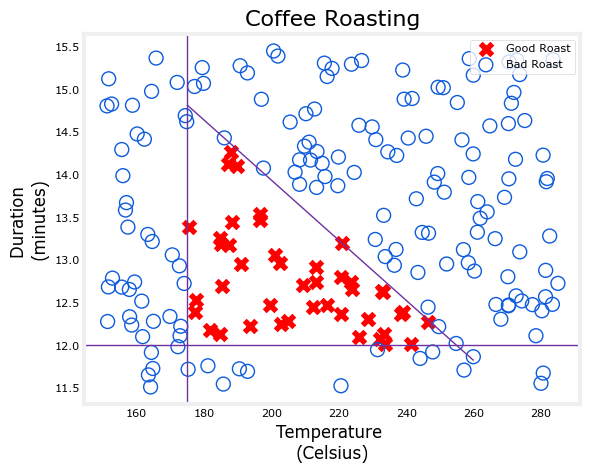

In [3]:
plt_roast(X,Y)

In [4]:
'''
create a "Normalization Layer". Note, as applied here, this is not a layer in your model.
'adapt' the data. This learns the mean and variance of the data set and saves the values internally.
normalize the data.
It is important to apply normalization to any future data that utilizes the learned model.
'''

print(f'temperature max,min pre normalization: {np.max(X[:,0]):0.2f}, {np.min(X[:,0]):.2f}')
print(f'Duration max,min pre normalization: {np.max(X[:,1]):0.2f}, {np.min(X[:,1]):.2f}')

# after noramlization
norm_layer=Normalization(axis=-1)
norm_layer.adapt(X) # learn mean, varience
X_norm=norm_layer(X)

print(f'temperature max,min post normalization: {np.max(X_norm[:,0]):0.2f}, {np.min(X_norm[:,0]):.2f}')
print(f'Duration max,min post normalization: {np.max(X_norm[:,1]):0.2f}, {np.min(X_norm[:,1]):.2f}')

temperature max,min pre normalization: 284.99, 151.32
Duration max,min pre normalization: 15.45, 11.51
temperature max,min post normalization: 1.66, -1.69
Duration max,min post normalization: 1.79, -1.70


In [5]:
'''
np.tile(): method is a NumPy array repetition utility. It is used to repeat an array along specified dimensions, producing a larger array by tiling the original pattern.
np.tile(A, reps)
A=input array
reps=repitions
'''

Xt=np.tile(X_norm,(1000,1))
Yt=np.tile(Y,(1000,1))
print(Xt.shape,Yt.shape)


(200000, 2) (200000, 1)


In [6]:
tf.random.set_seed(1234) #applied to achieve consistent results

model=Sequential(
    [
    keras.layers.Input(shape=(2,)),
    Dense(units=3, activation='sigmoid',name='layer1'),
    Dense(units=1,activation='sigmoid',name='layer2')
    ]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
L1_num_params = 2 * 3 + 3   # W1 parameters  + b1 parameters
L2_num_params = 3 * 1 + 1   # W2 parameters  + b2 parameters
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params  )

L1 params =  9 , L2 params =  4


In [8]:
W1 = np.array([
    [-8.94,  0.29, 12.89],
    [-0.17, -7.34, 10.79]] )
b1 = np.array([-9.87, -9.28,  1.01])
W2 = np.array([
    [-31.38],
    [-27.86],
    [-32.79]])
b2 = np.array([15.54])
model.get_layer("layer1").set_weights([W1,b1])
model.get_layer("layer2").set_weights([W2,b2])
print("W1:\n", W1, "\nb1:", b1)
print("W2:\n", W2, "\nb2:", b2)

W1:
 [[-8.94  0.29 12.89]
 [-0.17 -7.34 10.79]] 
b1: [-9.87 -9.28  1.01]
W2:
 [[-31.38]
 [-27.86]
 [-32.79]] 
b2: [15.54]


In [9]:
'''
model.compile() : this defines a loss function and specifies a compile optimization
model.fit(): this runs gradient descent and fits the weights to the data 
'''

model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=0.01)
)

model.fit(
    Xt,Yt,
    epochs=10
)

Epoch 1/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 5s 670us/step - loss: 0.0066
Epoch 2/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 691us/step - loss: 0.0047
Epoch 3/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 660us/step - loss: 0.0034
Epoch 4/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 632us/step - loss: 0.0024
Epoch 5/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 647us/step - loss: 0.0018
Epoch 6/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 668us/step - loss: 0.0013
Epoch 7/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 664us/step - loss: 0.0010
Epoch 8/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 666us/step - loss: 7.7237e-04
Epoch 9/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 5s 855us/step - loss: 6.0023e-04
Epoch 10/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 5s 747us/step - loss: 4.7158e-04


In [10]:
W1,b1=model.get_layer('layer1').get_weights()
W2,b2=model.get_layer('layer2').get_weights()

print("W1:\n", W1, "\nb1:", b1)
print("W2:\n", W2, "\nb2:", b2)

W1:
 [[-11.87  -0.18  15.61]
 [ -0.25  -9.47  13.02]] 
b1: [-12.85 -11.72   2.21]
W2:
 [[-68.54]
 [-64.35]
 [-55.98]] 
b2: [37.98]


In [11]:
# lets make prediction
X_test=np.array([
    [200,13.9],
    [200,17]]
)
X_test_norm=norm_layer(X_test)
predictions=model.predict(X_test_norm)
print("predictions = \n", predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
predictions = 
 [[9.95e-01]
 [1.50e-08]]


In [12]:
yhat=np.zeros_like(predictions)
for i in range(len(predictions)):
    if predictions[i]>=0.5:
        yhat[i]=1
    else:
        yhat[i]=0

print(f'decisions = \n{yhat}')


decisions = 
[[1.]
 [0.]]


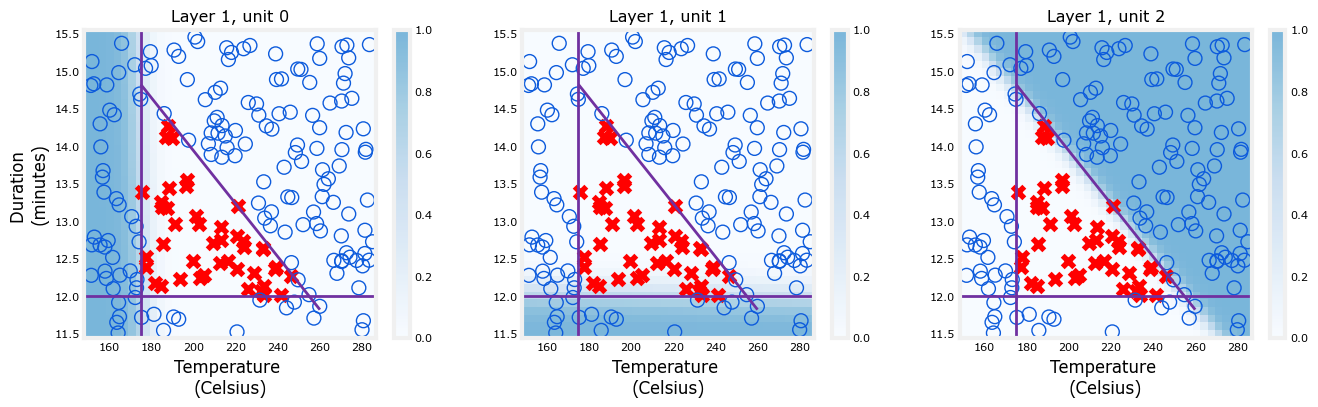

In [13]:
plt_layer(X,Y.reshape(-1,),W1,b1,norm_layer)

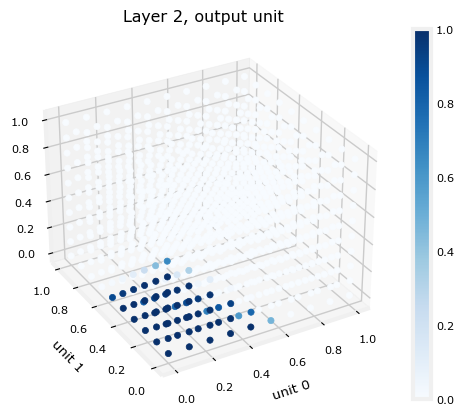

In [14]:
plt_output_unit(W2,b2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━

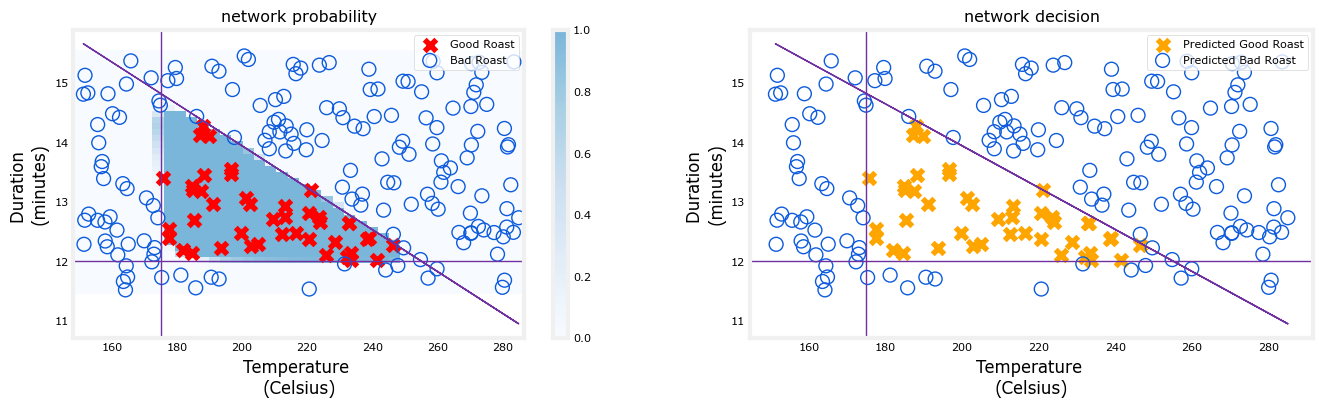

In [15]:
netf=lambda x: model.predict(norm_layer(x))
plt_network(X,Y,netf)